In [1]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

  Cloning https://github.com/NetManAIOps/sktime.git to /tmp/pip-req-build-frpfupjd
  Running command git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /tmp/pip-req-build-frpfupjd
  Resolved https://github.com/NetManAIOps/sktime.git to commit a2ab7b6a1928be24d8e127774f15d366e26d4017
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 5.8 MB/s eta 0:00:00
  Created wheel for sktime: filename=sktime-0.40.1-py3-none-any.whl size=36374090 sha256=e1eedc9ceec417fd0a1c16506de6f4e71904e409f40da7d10e27a0f62ad28396
  Stored in directory: /tmp/pip-ephem-wheel-cache-cgy1txwx/wheels/03/7e/fc/e38659894f6e29738ddf041859f11a018ea4f170d796e6ba4e
Successfully built sktime


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
rng = np.random.default_rng(7)

# ------------------------------
# 1) Simulate a compact DFM
# ------------------------------
T = 180       # time points
m = 6         # observed series
r = 2         # latent factors

t = np.arange(T)

# Latent factors follow VAR(1): f_t = A f_{t-1} + u_t
A_true = np.array([
    [0.78, 0.18],
    [-0.12, 0.72],
])
U = 0.12 * rng.multivariate_normal(mean=np.zeros(r), cov=np.array([[1.0, 0.35], [0.35, 1.0]]), size=T).T
F_true = np.zeros((r, T))
F_true[:, 0] = U[:, 0]
for k in range(1, T):
    F_true[:, k] = A_true @ F_true[:, k - 1] + U[:, k]

# Loadings (fixed, simple)
Lambda = np.array([
    [ 1.0,  0.4],
    [ 0.8, -0.2],
    [ 0.5,  1.0],
    [-0.6,  0.7],
    [ 0.3, -0.8],
    [-1.0,  0.5],
])  # m x r

# Idiosyncratic AR(1) noise (DFM flavor)
eta = 0.15 * rng.normal(size=(m, T))
epsilon = np.zeros((m, T))
epsilon[:, 0] = eta[:, 0]
for k in range(1, T):
    epsilon[:, k] = 0.55 * epsilon[:, k-1] + eta[:, k]

# Observed data
X = Lambda @ F_true + epsilon  # m x T

# Center
X_mean = X.mean(axis=1, keepdims=True)
Xc = X - X_mean

In [ ]:
# ------------------------------
# 2) Two-step estimation: PCA factors, then VAR(1)
# ------------------------------
U_svd, S_svd, Vt_svd = np.linalg.svd(Xc, full_matrices=False)

U_r = U_svd[:, :r]
S_r = S_svd[:r]
Vt_r = Vt_svd[:r, :]

X_hat = U_r @ np.diag(S_r) @ Vt_r        # common component
F_hat = np.diag(S_r) @ Vt_r              # r x T (up to rotation/scale)

# Align estimated factors to true factors via linear LS: minimize ||F_true - R F_hat||_F
R = F_true @ F_hat.T @ np.linalg.pinv(F_hat @ F_hat.T)
F_hat_aligned = R @ F_hat

# Step 2: VAR(1) on aligned factors: f_t = A f_{t-1} + u_t
F_prev = F_hat_aligned[:, :-1]
F_next = F_hat_aligned[:, 1:]
A_hat = F_next @ F_prev.T @ np.linalg.pinv(F_prev @ F_prev.T)

print("True transition matrix A (2x2):")
print(np.round(A_true, 3))
print("Estimated transition matrix A_hat (2x2):")
print(np.round(A_hat, 3))

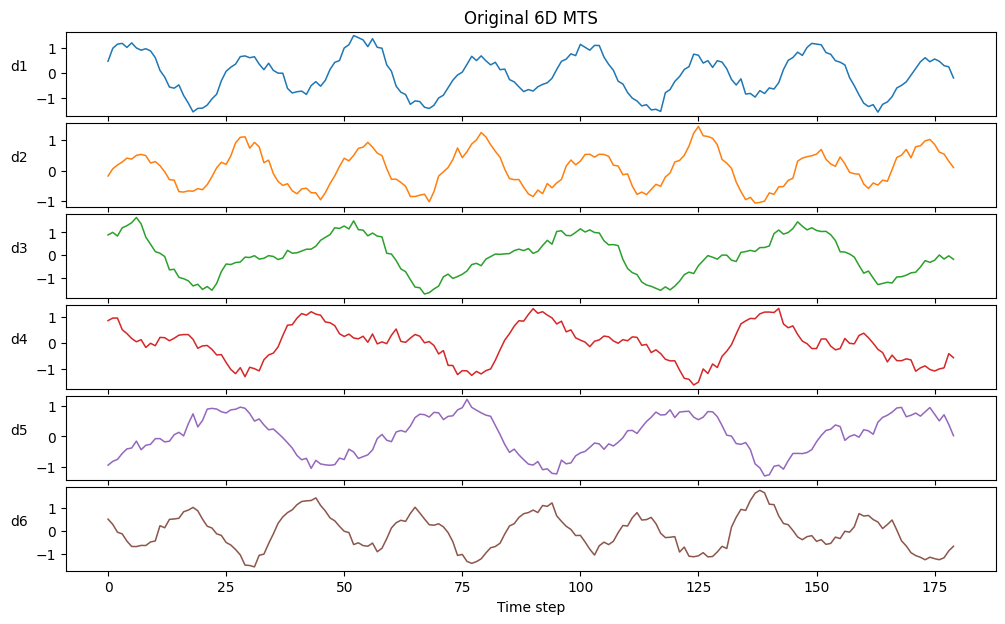

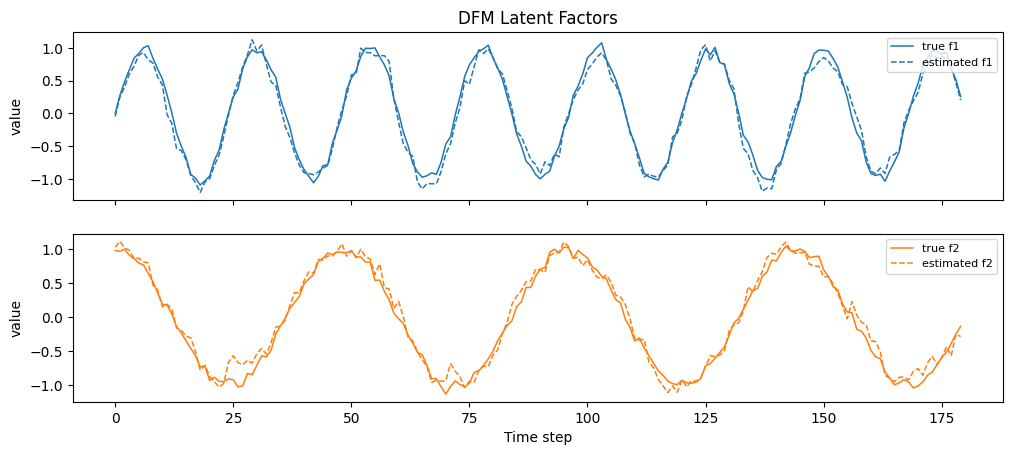

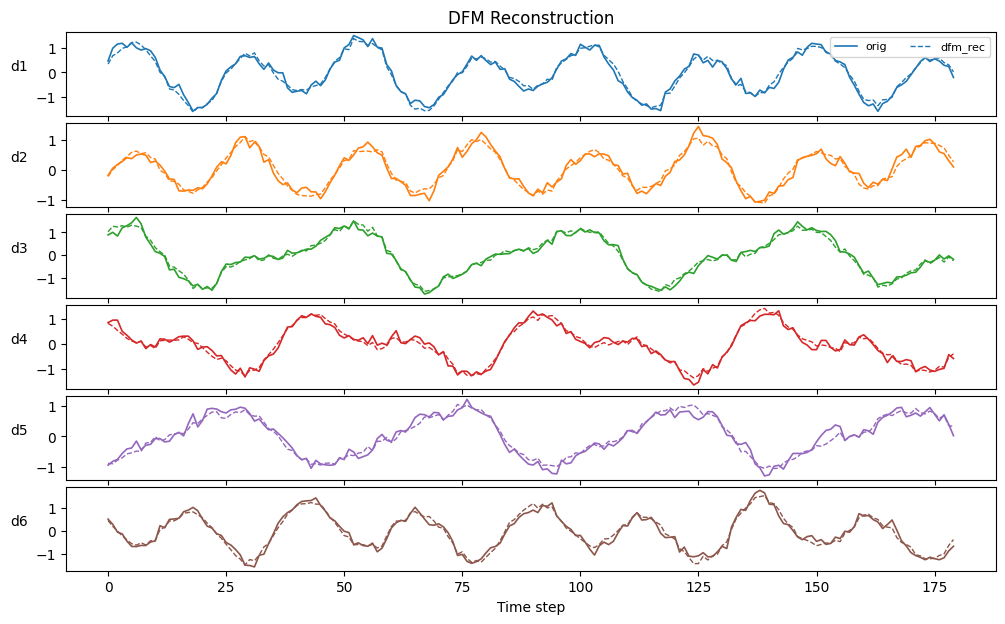

Variance explained by r=2 factors: 0.964


In [8]:
# ------------------------------
# 3) Visualizations
# ------------------------------

# (a) Original 6D MTS (compact 6x1)
dim_colors = plt.cm.tab10(np.arange(m))
fig, axes = plt.subplots(m, 1, figsize=(12, 7), sharex=True)
for i in range(m):
    axes[i].plot(t, X[i, :], color=dim_colors[i], linewidth=1.1)
    axes[i].set_ylabel(f"d{i+1}", rotation=0, labelpad=12)
axes[0].set_title("Original 6D MTS")
axes[-1].set_xlabel("Time step")
fig.subplots_adjust(hspace=0.08)
plt.show()

# (b) Latent factors (2D): true vs estimated-aligned
fig, axes = plt.subplots(r, 1, figsize=(12, 4.8), sharex=True)
factor_colors = ["tab:blue", "tab:orange"]
for i in range(r):
    axes[i].plot(t, F_true[i, :], color=factor_colors[i], linewidth=1.1, label=f"true f{i+1}")
    axes[i].plot(t, F_hat_aligned[i, :], color=factor_colors[i], linewidth=1.1, linestyle="--", label=f"estimated f{i+1}")
    axes[i].set_ylabel("value")
    axes[i].legend(loc="upper right", fontsize=8)
axes[0].set_title("DFM Latent Factors")
axes[-1].set_xlabel("Time step")
fig.subplots_adjust(hspace=0.20)
plt.show()

# (c) Reconstruction comparison (6x1): orig vs dfm_rec
X_rec = X_hat + X_mean
fig, axes = plt.subplots(m, 1, figsize=(12, 7), sharex=True)
for i in range(m):
    c = dim_colors[i]
    axes[i].plot(t, X[i, :], color=c, linewidth=1.2, linestyle="-", label="orig")
    axes[i].plot(t, X_rec[i, :], color=c, linewidth=1.0, linestyle="--", label="dfm_rec")
    axes[i].set_ylabel(f"d{i+1}", rotation=0, labelpad=12)
axes[0].set_title("DFM Reconstruction")
axes[0].legend(loc="upper right", ncol=2, fontsize=8)
axes[-1].set_xlabel("Time step")
fig.subplots_adjust(hspace=0.08)
plt.show()

# (d) Variance explained
ss_total = np.sum((Xc)**2)
ss_common = np.sum((X_hat)**2)
ve = ss_common / ss_total
print(f"Variance explained by r={r} factors: {ve:.3f}")